<a href="https://colab.research.google.com/github/keertish05/big_data_project/blob/main/PS4_HospitalAlertSystem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Spark session initialized successfully!
Generating synthetic healthcare data...
Generated demographics.csv with 500 records
Generated claims.parquet with 1000 records
Generated streaming_vitals.json with 2000 records
Loading data...
Data loaded successfully!
Demographics count: 500
Claims count: 1000
Vitals count: 2000

Demographics schema:
root
 |-- patient_id: string (nullable = true)
 |-- hospital_id: string (nullable = true)
 |-- city: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)


Claims schema:
root
 |-- claim_id: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- hospital_id: string (nullable = true)
 |-- claim_amount: long (nullable = true)
 |-- procedure: string (nullable = true)
 |-- claim_date: string (nullable = true)


Vitals schema:
root
 |-- body_temperature: double (nullable = true)
 |-- diastolic_bp: long (nullable = true)
 |-- heart_rate: long (nullable = true)
 |-- patient_id: string (nullable

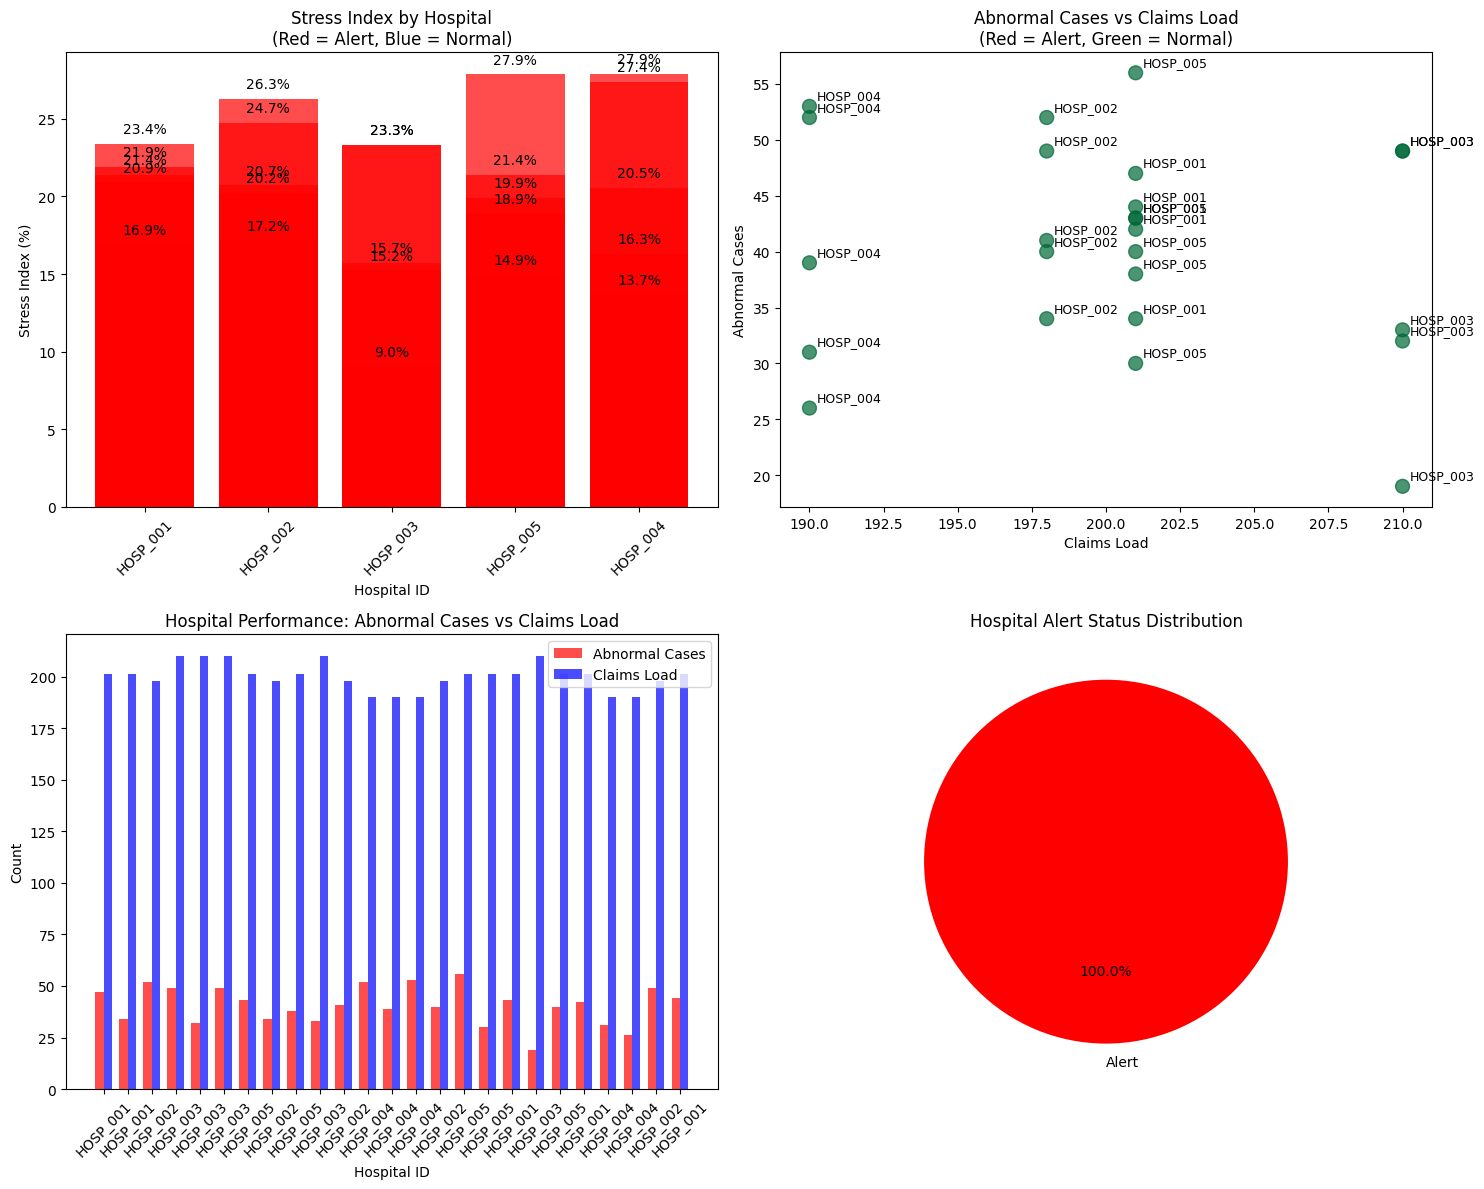


DETAILED ANALYSIS
Hospital Stress Analysis:
hospital_id      city  total_vitals  abnormal_cases  claims_load  stress_index  alert alert_status
   HOSP_001   Chennai            90              47          201         23.38      1      🚨 ALERT
   HOSP_001     Delhi            70              34          201         16.92      1      🚨 ALERT
   HOSP_002   Chennai           116              52          198         26.26      1      🚨 ALERT
   HOSP_003    Mumbai            88              49          210         23.33      1      🚨 ALERT
   HOSP_003 Bangalore            62              32          210         15.24      1      🚨 ALERT
   HOSP_003   Kolkata            98              49          210         23.33      1      🚨 ALERT
   HOSP_005   Chennai            79              43          201         21.39      1      🚨 ALERT
   HOSP_002 Bangalore            57              34          198         17.17      1      🚨 ALERT
   HOSP_005    Mumbai            74              38          201

In [1]:
# Install required packages
!pip install pyspark seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, count, sum as spark_sum
import random
from datetime import datetime, timedelta

# Initialize Spark Session
spark = SparkSession.builder \
    .appName("HospitalAlertSystem") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

print("Spark session initialized successfully!")

# =============================================================================
# 1. SYNTHETIC DATA GENERATION (Since original files don't exist in Colab)
# =============================================================================

def generate_synthetic_data():
    """Generate synthetic datasets for the hospital alert system"""

    # Create hospital IDs and cities
    hospitals = ["HOSP_001", "HOSP_002", "HOSP_003", "HOSP_004", "HOSP_005"]
    cities = ["Delhi", "Mumbai", "Chennai", "Bangalore", "Kolkata"]

    # --- Demographics Data ---
    demographics_data = []
    for i in range(1, 501):  # 500 patients
        patient_id = f"P{1000 + i}"
        hospital_id = random.choice(hospitals)
        city = random.choice(cities)
        age = random.randint(20, 80)
        gender = random.choice(["Male", "Female"])

        demographics_data.append({
            "patient_id": patient_id,
            "hospital_id": hospital_id,
            "city": city,
            "age": age,
            "gender": gender
        })

    demographics_df = pd.DataFrame(demographics_data)
    demographics_df.to_csv("demographics.csv", index=False)
    print(f"Generated demographics.csv with {len(demographics_df)} records")

    # --- Claims Data ---
    claims_data = []
    for i in range(1, 1001):  # 1000 claims
        claim_id = f"CLM{5000 + i}"
        patient_id = f"P{1000 + random.randint(1, 500)}"
        hospital_id = random.choice(hospitals)
        claim_amount = random.randint(1000, 50000)
        procedure = random.choice(["Surgery", "Consultation", "Lab Test", "Medication"])
        claim_date = (datetime.now() - timedelta(days=random.randint(0, 30))).strftime("%Y-%m-%d")

        claims_data.append({
            "claim_id": claim_id,
            "patient_id": patient_id,
            "hospital_id": hospital_id,
            "claim_amount": claim_amount,
            "procedure": procedure,
            "claim_date": claim_date
        })

    claims_df = pd.DataFrame(claims_data)
    claims_df.to_parquet("claims.parquet", index=False)
    print(f"Generated claims.parquet with {len(claims_df)} records")

    # --- Streaming Vitals Data ---
    vitals_data = []
    for i in range(1, 2001):  # 2000 vitals records
        patient_id = f"P{1000 + random.randint(1, 500)}"
        body_temperature = round(random.uniform(97.0, 104.0), 1)
        heart_rate = random.randint(60, 120)
        systolic_bp = random.randint(90, 160)
        diastolic_bp = random.randint(60, 100)
        timestamp = (datetime.now() - timedelta(hours=random.randint(0, 168))).strftime("%Y-%m-%d %H:%M:%S")

        vitals_data.append({
            "patient_id": patient_id,
            "body_temperature": body_temperature,
            "heart_rate": heart_rate,
            "systolic_bp": systolic_bp,
            "diastolic_bp": diastolic_bp,
            "timestamp": timestamp
        })

    # Save as JSON
    import json
    with open("streaming_vitals.json", "w") as f:
        for record in vitals_data:
            f.write(json.dumps(record) + '\n')
    print(f"Generated streaming_vitals.json with {len(vitals_data)} records")

    return demographics_df, claims_df, vitals_data

print("Generating synthetic healthcare data...")
demographics_df, claims_df, vitals_data = generate_synthetic_data()

# =============================================================================
# 2. DATA PROCESSING PIPELINE
# =============================================================================

# 1. Load DataFrames (Structured Data)
print("Loading data...")
demographics = spark.read.csv("demographics.csv", header=True, inferSchema=True)
demographics.cache()

claims = spark.read.parquet("claims.parquet")
claims.cache()

vitals = spark.read.json("streaming_vitals.json")
vitals.cache()

print("Data loaded successfully!")
print(f"Demographics count: {demographics.count()}")
print(f"Claims count: {claims.count()}")
print(f"Vitals count: {vitals.count()}")

# Show schemas
print("\nDemographics schema:")
demographics.printSchema()

print("\nClaims schema:")
claims.printSchema()

print("\nVitals schema:")
vitals.printSchema()

# 2. Join Vitals + Demographics to map to hospital_id, city/region
print("\nJoining vitals with demographics...")
vitals_join = vitals.join(demographics, on=["patient_id"], how="left").cache()
print(f"Joined vitals-demographics count: {vitals_join.count()}")

# 3. Flag abnormal vitals (fever: temp > 100.4)
print("\nFlagging abnormal vitals...")
vitals_abn = vitals_join.withColumn(
    "abnormal_flag", when(col("body_temperature") > 100.4, 1).otherwise(0)
).cache()

abnormal_count = vitals_abn.filter(col("abnormal_flag") == 1).count()
total_count = vitals_abn.count()
print(f"Abnormal vitals: {abnormal_count}/{total_count} ({abnormal_count/total_count*100:.1f}%)")

# 4. Aggregate: Abnormal vitals per hospital or region
print("\nAggregating vitals by hospital...")
vitals_agg = vitals_abn.groupBy("hospital_id", "city").agg(
    count("*").alias("total_vitals"),
    spark_sum("abnormal_flag").alias("abnormal_cases")
).cache()

print("Vitals aggregation by hospital:")
vitals_agg.show()

# 5. Aggregate: Claims per hospital/region
print("\nAggregating claims by hospital...")
claims_agg = claims.groupBy("hospital_id").agg(
    count("*").alias("claims_load")
).cache()

print("Claims aggregation by hospital:")
claims_agg.show()

# 6. Merge aggregations for each hospital
print("\nMerging vitals and claims data...")
alert_df = vitals_agg.join(claims_agg, on="hospital_id", how="left").fillna(0).cache()

print("Merged data:")
alert_df.show()

# 7. Compute Stress Index and Alerts
print("\nComputing stress index and alerts...")
alert_df = alert_df.withColumn(
    "stress_index",
    when(col("claims_load") > 0, (col("abnormal_cases") / col("claims_load")) * 100)
    .otherwise(0)
)

alert_df = alert_df.withColumn(
    "alert",
    when((col("abnormal_cases") > 10) & (col("claims_load") > 50), 1).otherwise(0)
)

print("Final alert data with stress index:")
alert_df.show()

# Convert to pandas for visualization
alert_pd = alert_df.toPandas()
alert_pd.to_csv("ps4_hospital_alert_output.csv", index=False)
print("\nSaved results to ps4_hospital_alert_output.csv")

# =============================================================================
# 3. VISUALIZATIONS
# =============================================================================

print("\n" + "="*50)
print("HOSPITAL ALERT DASHBOARD")
print("="*50)

# Create visualizations
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Stress Index Bar Plot
if not alert_pd.empty:
    # Bar plot with alerts
    colors = ['red' if alert else 'blue' for alert in alert_pd['alert']]
    bars = axes[0, 0].bar(alert_pd['hospital_id'], alert_pd['stress_index'], color=colors, alpha=0.7)
    axes[0, 0].set_xlabel('Hospital ID')
    axes[0, 0].set_ylabel('Stress Index (%)')
    axes[0, 0].set_title('Stress Index by Hospital\n(Red = Alert, Blue = Normal)')
    axes[0, 0].tick_params(axis='x', rotation=45)

    # Add value labels on bars
    for bar, value in zip(bars, alert_pd['stress_index']):
        axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                       f'{value:.1f}%', ha='center', va='bottom', fontsize=10)

# 2. Abnormal Cases vs Claims Load
if not alert_pd.empty:
    scatter = axes[0, 1].scatter(alert_pd['claims_load'], alert_pd['abnormal_cases'],
                                c=alert_pd['alert'], cmap='RdYlGn_r', s=100, alpha=0.7)
    axes[0, 1].set_xlabel('Claims Load')
    axes[0, 1].set_ylabel('Abnormal Cases')
    axes[0, 1].set_title('Abnormal Cases vs Claims Load\n(Red = Alert, Green = Normal)')

    # Add hospital labels
    for i, row in alert_pd.iterrows():
        axes[0, 1].annotate(row['hospital_id'],
                           (row['claims_load'], row['abnormal_cases']),
                           xytext=(5, 5), textcoords='offset points', fontsize=9)

# 3. Hospital Performance Comparison
if not alert_pd.empty:
    x_pos = range(len(alert_pd))
    width = 0.35

    axes[1, 0].bar([p - width/2 for p in x_pos], alert_pd['abnormal_cases'], width,
                   label='Abnormal Cases', color='red', alpha=0.7)
    axes[1, 0].bar([p + width/2 for p in x_pos], alert_pd['claims_load'], width,
                   label='Claims Load', color='blue', alpha=0.7)

    axes[1, 0].set_xlabel('Hospital ID')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].set_title('Hospital Performance: Abnormal Cases vs Claims Load')
    axes[1, 0].set_xticks(x_pos)
    axes[1, 0].set_xticklabels(alert_pd['hospital_id'])
    axes[1, 0].legend()
    axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Alert Status Pie Chart - FIXED VERSION
if not alert_pd.empty:
    # Count alerts by status
    alert_counts = alert_pd['alert'].value_counts().sort_index()

    # Create labels and colors based on actual data
    labels = []
    colors = []

    if len(alert_counts) == 2:  # Both alert and normal present
        labels = ['Normal', 'Alert']
        colors = ['lightgreen', 'red']
    elif 1 in alert_counts.index:  # Only alerts present
        labels = ['Alert']
        colors = ['red']
    elif 0 in alert_counts.index:  # Only normal present
        labels = ['Normal']
        colors = ['lightgreen']

    if labels:  # Only create pie chart if we have data
        axes[1, 1].pie(alert_counts.values, labels=labels, colors=colors,
                      autopct='%1.1f%%', startangle=90)
        axes[1, 1].set_title('Hospital Alert Status Distribution')
    else:
        axes[1, 1].text(0.5, 0.5, 'No alert data available',
                       ha='center', va='center', transform=axes[1, 1].transAxes)
        axes[1, 1].set_title('Hospital Alert Status Distribution')

plt.tight_layout()
plt.savefig('ps4_stress_index_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# 4. DETAILED ANALYSIS AND SUMMARY
# =============================================================================

print("\n" + "="*50)
print("DETAILED ANALYSIS")
print("="*50)

# Display detailed table
if not alert_pd.empty:
    display_table = alert_pd[['hospital_id', 'city', 'total_vitals', 'abnormal_cases',
                            'claims_load', 'stress_index', 'alert']].copy()
    display_table['stress_index'] = display_table['stress_index'].round(2)
    display_table['alert_status'] = display_table['alert'].map({1: '🚨 ALERT', 0: '✅ Normal'})

    print("Hospital Stress Analysis:")
    print(display_table.to_string(index=False))

# Summary Statistics
print("\n" + "="*50)
print("SUMMARY STATISTICS")
print("="*50)
print(f"Total hospitals analyzed: {len(alert_pd)}")
print(f"Hospitals in alert state: {alert_pd['alert'].sum()}")
print(f"Average stress index: {alert_pd['stress_index'].mean():.2f}%")
print(f"Maximum stress index: {alert_pd['stress_index'].max():.2f}%")
print(f"Total abnormal cases detected: {alert_pd['abnormal_cases'].sum()}")
print(f"Total claims processed: {alert_pd['claims_load'].sum()}")

# Alert Details
alerts = alert_pd[alert_pd['alert'] == 1]
if not alerts.empty:
    print(f"\n🚨 HOSPITALS IN ALERT STATE:")
    for _, hospital in alerts.iterrows():
        print(f"  - {hospital['hospital_id']} ({hospital['city']}): "
              f"{hospital['abnormal_cases']} abnormal cases, "
              f"{hospital['claims_load']} claims, "
              f"Stress Index: {hospital['stress_index']:.1f}%")

# Additional: Hospital-wise summary
print(f"\n🏥 HOSPITAL-WISE SUMMARY:")
hospital_summary = alert_pd.groupby('hospital_id').agg({
    'abnormal_cases': 'sum',
    'claims_load': 'mean',  # Since claims_load is same for each hospital_id
    'stress_index': 'mean',
    'alert': 'max'
}).reset_index()

for _, hospital in hospital_summary.iterrows():
    status = "🚨 ALERT" if hospital['alert'] == 1 else "✅ Normal"
    print(f"  - {hospital['hospital_id']}: {status}, "
          f"Avg Stress: {hospital['stress_index']:.1f}%, "
          f"Total Abnormal Cases: {hospital['abnormal_cases']:.0f}")

# =============================================================================
# 5. CLEANUP
# =============================================================================

# Unpersist cached DataFrames
try:
    demographics.unpersist()
    claims.unpersist()
    vitals.unpersist()
    vitals_join.unpersist()
    vitals_abn.unpersist()
    vitals_agg.unpersist()
    claims_agg.unpersist()
    alert_df.unpersist()
    print("\nAll DataFrames unpersisted successfully!")
except:
    print("\nSome DataFrames may have already been unpersisted")

# Stop Spark session
spark.stop()
print("Spark session stopped successfully!")

print("\n" + "="*50)
print("PIPELINE EXECUTION COMPLETED!")
print("="*50)
print("Generated files:")
print("✅ ps4_hospital_alert_output.csv")
print("✅ ps4_stress_index_dashboard.png")
print("="*50)

# List generated files
print("\nGenerated files list:")
import os
files = [f for f in os.listdir('.') if f.endswith(('.csv', '.png', '.parquet', '.json'))]
for file in files:
    print(f"📄 {file}")